In [1]:
"""
v10_subgraph_portfolio.py
----------------------------
Personal Investment Research Assistant -- SUBGRAPH + SEND version.

This version answers: "Analyze every stock in my portfolio" by running a
reusable "analyze one stock" SUBGRAPH once per holding, IN PARALLEL, via
Send -- then synthesizes all the individual results into one portfolio
overview.

It deliberately contains TWO different kinds of parallelism side by side,
so the distinction is concrete rather than just described:

    INSIDE the subgraph (one stock):
        fetch_price, fetch_info, fetch_news all run in PLAIN PARALLEL
        EDGES from START. This is a FIXED, KNOWN branch count -- always
        exactly 3 -- so no Send is needed here. Multiple add_edge() calls
        from the same source node already run their targets in parallel;
        Send is for when the NUMBER of branches isn't known until runtime.

    IN THE PARENT graph (the whole portfolio):
        the number of stocks is NOT known until runtime -- a portfolio
        could have 1 holding or 50. THIS is exactly the case Send is for:
        one Send("analyze_stock", {"ticker": t}) per holding, dispatched
        dynamically based on how many tickers are actually in the list.

Pipeline, in plain English:

    SUBGRAPH ("analyze one stock"):
        fetch_price / fetch_info / fetch_news (parallel, fixed count)
            -> summarize_stock (waits for all three, writes one summary)

    PARENT graph ("analyze a portfolio"):
        dispatch_to_analysis (Send, one per ticker, dynamic count)
            -> analyze_stock  <-- THIS NODE IS THE COMPILED SUBGRAPH ITSELF
            -> (LangGraph waits for every parallel subgraph run to finish)
            -> synthesize_portfolio (combines every stock's summary into
               one overview)
"""

import os
import operator
from typing import List, Dict, Annotated, TypedDict

from langchain_together import ChatTogether
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

import yfinance as yf

from dotenv import load_dotenv
load_dotenv(".env")

# ---------------------------------------------------------------------------
# 1. LLM SETUP
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# ---------------------------------------------------------------------------
# 2. SUBGRAPH: "analyze one stock"
#
#    This is a COMPLETE, INDEPENDENTLY COMPILABLE graph. It has no idea it
#    will later be embedded inside a bigger graph -- that's the whole point
#    of a subgraph: it's a self-contained, reusable unit that could just as
#    easily be tested, run, or reused entirely on its own.
# ---------------------------------------------------------------------------

class StockAnalysisState(TypedDict):
    ticker: str              # input: which stock to analyze
    price_info: str          # filled by fetch_price
    company_info: str        # filled by fetch_info
    news_info: str           # filled by fetch_news

    stock_summaries: Annotated[List[Dict], operator.add]
    # OUTPUT field. Deliberately given the SAME NAME and SAME REDUCER TYPE
    # as the parent graph's corresponding field (see PortfolioState below).
    # This shared name is what lets a result produced INSIDE this subgraph
    # flow back up and merge correctly into the PARENT's list when this
    # subgraph is later run as one of several parallel Send branches --
    # LangGraph matches state keys by name across the subgraph/parent
    # boundary, and applies whichever reducer the PARENT graph declared for
    # that key when combining results from multiple parallel runs.


def fetch_price(state: StockAnalysisState) -> dict:
    try:
        info = yf.Ticker(state["ticker"]).info
        price = info.get("currentPrice") or info.get("regularMarketPrice")
        prev_close = info.get("previousClose")
        change_pct = ((price - prev_close) / prev_close * 100) if (price and prev_close) else None
        change_str = f"{change_pct:+.2f}%" if change_pct is not None else "unknown change"
        return {"price_info": f"${price:.2f} ({change_str} today)" if price else "Price unavailable"}
    except Exception as e:
        return {"price_info": f"Error fetching price: {e}"}


def fetch_info(state: StockAnalysisState) -> dict:
    try:
        info = yf.Ticker(state["ticker"]).info
        sector = info.get("sector", "unknown sector")
        market_cap = info.get("marketCap")
        market_cap_str = f"${market_cap / 1e9:.1f}B" if market_cap else "unknown"
        return {"company_info": f"Sector: {sector}. Market cap: {market_cap_str}."}
    except Exception as e:
        return {"company_info": f"Error fetching info: {e}"}


def fetch_news(state: StockAnalysisState) -> dict:
    try:
        news_items = yf.Ticker(state["ticker"]).news or []
        titles = []
        for item in news_items[:2]:
            title = item.get("content", {}).get("title") or item.get("title")
            if title:
                titles.append(title)
        return {"news_info": "; ".join(titles) if titles else "No recent news."}
    except Exception as e:
        return {"news_info": f"Error fetching news: {e}"}


SUMMARY_PROMPT = """Summarize this stock in 2-3 short sentences for an individual investor,
mentioning anything notable about price movement, sector/size, or recent news.

Ticker: {ticker}
Price info: {price_info}
Company info: {company_info}
Recent news: {news_info}
"""


def summarize_stock(state: StockAnalysisState) -> dict:
    """
    Runs AFTER fetch_price/fetch_info/fetch_news all finish (LangGraph
    waits for every parallel branch feeding into this node before running
    it). Produces the subgraph's actual output: one entry in
    stock_summaries.
    """
    summary = llm.invoke(
        SUMMARY_PROMPT.format(
            ticker=state["ticker"],
            price_info=state["price_info"],
            company_info=state["company_info"],
            news_info=state["news_info"],
        )
    ).content

    return {"stock_summaries": [{"ticker": state["ticker"], "summary": summary}]}


stock_subgraph_builder = StateGraph(StockAnalysisState)
stock_subgraph_builder.add_node("fetch_price", fetch_price)
stock_subgraph_builder.add_node("fetch_info", fetch_info)
stock_subgraph_builder.add_node("fetch_news", fetch_news)
stock_subgraph_builder.add_node("summarize_stock", summarize_stock)

# Three PLAIN edges from START -- all three run in parallel automatically.
# This is NOT a Send fan-out: the branch count is fixed at exactly 3,
# known at graph-build time, so a normal edge for each is all that's needed.
stock_subgraph_builder.add_edge(START, "fetch_price")
stock_subgraph_builder.add_edge(START, "fetch_info")
stock_subgraph_builder.add_edge(START, "fetch_news")

# All three converge into summarize_stock -- LangGraph waits for every
# incoming edge before running a node, so this naturally waits for all 3.
stock_subgraph_builder.add_edge("fetch_price", "summarize_stock")
stock_subgraph_builder.add_edge("fetch_info", "summarize_stock")
stock_subgraph_builder.add_edge("fetch_news", "summarize_stock")

stock_subgraph_builder.add_edge("summarize_stock", END)

stock_subgraph = stock_subgraph_builder.compile()
# `stock_subgraph` is now a fully independent, runnable graph. You could
# call stock_subgraph.invoke({"ticker": "AAPL", ...}) right now, entirely
# on its own, with no knowledge of the parent graph below. That
# independence is exactly what makes it reusable as a subgraph.



In [5]:

# ---------------------------------------------------------------------------
# 3. PARENT GRAPH: "analyze a portfolio"
# ---------------------------------------------------------------------------

class PortfolioState(TypedDict):
    tickers: List[str]  # input: the whole portfolio

    stock_summaries: Annotated[List[Dict], operator.add]
    # Same name/reducer as the subgraph's output field above -- this is
    # the shared contract that lets N parallel subgraph runs each
    # contribute one entry, merged into one combined list.

    portfolio_overview: str  # final synthesized output


def dispatch_to_analysis(state: PortfolioState) -> List[Send]:
    """
    THIS is the Send fan-out -- the number of branches depends on
    len(state["tickers"]), which isn't known until the graph actually
    runs. Compare to the subgraph's fetch_price/fetch_info/fetch_news
    above, where the count (3) was fixed and known in advance.
    """
    return [
        Send("analyze_stock", {"ticker": ticker, "stock_summaries": []})
        for ticker in state["tickers"]
    ]


PORTFOLIO_OVERVIEW_PROMPT = """Here are summaries of every stock in an individual's portfolio.
Write a brief overall portfolio overview (3-4 sentences) -- mention any
notable sector concentration, standout movers, or general themes across
the holdings.

{summaries}
"""


def synthesize_portfolio(state: PortfolioState) -> dict:
    """
    Runs once, AFTER every parallel analyze_stock (subgraph) branch has
    finished -- same automatic wait behavior as the Send-based
    validate_instruction step in the MT599 pipeline.
    """
    summaries_text = "\n".join(
        f"- {item['ticker']}: {item['summary']}" for item in state["stock_summaries"]
    )
    overview = llm.invoke(PORTFOLIO_OVERVIEW_PROMPT.format(summaries=summaries_text)).content
    return {"portfolio_overview": overview}


portfolio_builder = StateGraph(PortfolioState)

# The compiled subgraph is added AS A NODE, directly -- this is the actual
# "subgraph" mechanic, not just a function call to .invoke() from inside
# another node. LangGraph treats `stock_subgraph` as a single unit here:
# from the parent's perspective, "analyze_stock" is just another node that
# happens to be, internally, a whole graph of its own.
portfolio_builder.add_node("analyze_stock", stock_subgraph)
portfolio_builder.add_node("synthesize_portfolio", synthesize_portfolio)

portfolio_builder.add_conditional_edges(START, dispatch_to_analysis, ["analyze_stock"])
portfolio_builder.add_edge("analyze_stock", "synthesize_portfolio")
portfolio_builder.set_finish_point("synthesize_portfolio")

portfolio_graph = portfolio_builder.compile()


In [7]:

# ---------------------------------------------------------------------------
# 4. VISUALIZE
#    xray=True expands any subgraph nodes in the diagram so you can see
#    fetch_price/fetch_info/fetch_news/summarize_stock nested INSIDE the
#    analyze_stock node, rather than a single opaque box.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str, xray: bool = False) -> None:
    try:
        png_bytes = compiled_graph.get_graph(xray=xray).draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")



Portfolio graph, COLLAPSED (subgraph shown as one box):


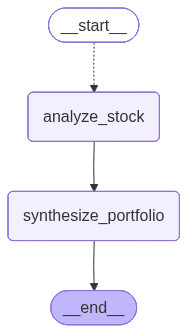


Portfolio graph, EXPANDED (xray=True -- subgraph internals visible):


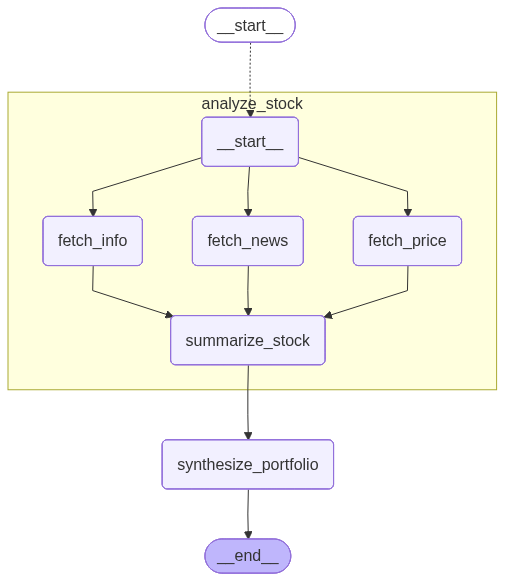


Analyzed 3 stocks in parallel:

AAPL: Apple (AAPL) is trading at $308.63, up 4.84% today, in the Technology sector with a market cap of $4533.0B. Recent news highlights include a comparison of dividend-growth ETFs and a Wall Street warning signaled by Apple's 2027 hardware refresh plans.

MSFT: Microsoft (MSFT) closed at $390.49, up 1.62% today, in the Technology sector with a market cap of $2900.7B. Notably, despite recent price movements, Bill Ackman remains cautious, suggesting other investors might also be hesitant.

NVDA: NVDA, a technology giant with a market cap of $4719.0B, saw a slight dip of 1.39% to $194.83 today. While recent news focused on oil and consumer goods, NVDA remains a key player in its sector.

PORTFOLIO OVERVIEW
Your portfolio is heavily weighted in the Technology sector, with significant positions in Apple (AAPL) and NVIDIA (NVDA), each valued at over $4 trillion in market cap. Apple has shown strong performance today, up 4.84%, driven by recent comparisons t

In [9]:

# ---------------------------------------------------------------------------
# 5. QUICK TEST
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    print("Portfolio graph, COLLAPSED (subgraph shown as one box):")
    visualize_graph(portfolio_graph, "graph_v10_collapsed.png", xray=False)

    print("\nPortfolio graph, EXPANDED (xray=True -- subgraph internals visible):")
    visualize_graph(portfolio_graph, "graph_v10_expanded.png", xray=True)

    portfolio = ["AAPL", "MSFT", "NVDA"]
    result = portfolio_graph.invoke({
        "tickers": portfolio,
        "stock_summaries": [],
        "portfolio_overview": "",
    })

    print("\n" + "=" * 70)
    print(f"Analyzed {len(result['stock_summaries'])} stocks in parallel:")
    print("=" * 70)
    for item in result["stock_summaries"]:
        print(f"\n{item['ticker']}: {item['summary']}")

    print("\n" + "=" * 70)
    print("PORTFOLIO OVERVIEW")
    print("=" * 70)
    print(result["portfolio_overview"])
